## 1. Data Processing

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OneHotEncoder

from matplotlib import font_manager
from datetime import datetime
import re
import json
import warnings

# Global Settings
warnings.filterwarnings('ignore')

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [2]:
# Choose rent or sale dataset
# isRent = True
isRent = False

# Choose whether to predict
# isPredict = False
isPredict = True

# Create a timestamped log file
filename_temp = datetime.now().strftime("%Y%m%d_%H%M%S") + "_execution_log.txt"

In [3]:
# Logging Function
def log_message(message, filename=filename_temp, iscurrenttime=False):
    """
    Write logs with or without a timestamp.
    """
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    if iscurrenttime:
        log_entry = f"[{timestamp}] {message}\n"
    else:
        log_entry = f"{message}\n"
    
    # Print log to console
    print(log_entry)
    
    # Save log to file
    with open(filename, "a", encoding="utf-8") as f:
        f.write(log_entry)


# Log the Modeling Type
if isRent:
    log_message("====== 租房建模与预测 ======")
else:
    log_message("====== 卖房建模与预测 ======")


# Font Configuration
# Set Chinese font to avoid garbled labels
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


# Record Start Time
current_time_start = datetime.now()

====== 卖房建模与预测 ======



In [4]:
# Load data
# When the data file is too large, it cannot be loaded into memory all at once
def load_housing_data_chunked(file_path, chunksize=10000):
    """Read data in chunks"""
    chunks = []
    for chunk in pd.read_csv(file_path, chunksize=chunksize):
        chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True)

# Load data (including training set + prediction set)
current_time_temp_start = datetime.now()
df = 0

if isRent:
    if isPredict:
        df_pred = load_housing_data_chunked("ruc_Class25Q2_test_rent.csv")
    df = load_housing_data_chunked("ruc_Class25Q2_train_rent.csv")
else:
    if isPredict:
        df_pred = load_housing_data_chunked("ruc_Class25Q2_test_price.csv")
    df = load_housing_data_chunked("ruc_Class25Q2_train_price.csv")

current_time_temp_end = datetime.now()
duration = current_time_temp_end - current_time_temp_start
log_message(f"执行时长: {duration}")
log_message(f"数据维度: {df.shape}")

执行时长: 0:00:06.565416

数据维度: (103871, 55)



### 1.1 Data Inspection

In [5]:
# Preliminary data exploration
print("Data Inspection")

# View basic information
print("数据类型信息：")
print(str(df.dtypes.value_counts()))

print("前五行示例：")
print(df.head())

# Descriptive statistics
print("数值型变量描述性统计（前10列）：")
print(str(df.describe().iloc[:, :10]))

Data Inspection
数据类型信息：
object     41
float64    13
int64       1
Name: count, dtype: int64
前五行示例：
   城市     区域      板块    环线         Price      房屋户型        所在楼层     建筑面积     套内面积     房屋朝向  建筑结构 装修情况   梯户比例 配备电梯 别墅类型        交易时间 交易权属        上次交易   房屋用途 房屋年限 产权所属  抵押信息         房屋优势  \
0   0  109.0   150.0  二至三环  6.194049e+06  2室1厅1厨1卫   中楼层 (共5层)    52.3㎡      NaN      南 北  混合结构   精装   一梯三户    无  NaN  2021-03-29  商品房  2013-07-31   普通住宅  满五年  非共有   NaN     装修、房本满五年   
1   0   65.0   299.0  五至六环  4.354153e+06  3室1厅1厨1卫    顶层 (共6层)  127.44㎡   123.7㎡      南 北  混合结构   精装   一梯两户    无  NaN  2020-10-29  商品房  2010-12-10   普通住宅  满五年  非共有   NaN     装修、房本满五年   
2   0   62.0   911.0  五至六环  3.321992e+06  3室2厅1厨2卫   低楼层 (共6层)  118.02㎡  101.95㎡       东南  钢混结构   简装   一梯五户    有  NaN  2020-11-24  商品房  2013-10-28   普通住宅  满五年  非共有   NaN  地铁、装修、房本满五年   
3   0  123.0  1102.0   六环外  7.895656e+06  6室3厅1厨3卫    底层 (共2层)  293.23㎡  293.23㎡  东 南 西 北  混合结构   精装    NaN  NaN   独栋  2023-03-10  商品房  2017-04-12     别墅  满五

In [6]:
# Descriptive Statistics
print("\n--- Summary Statistics: Price Dataset ---")
display(df.describe(include='all').T)


--- Summary Statistics: Price Dataset ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
城市,103871.0,NaN,NaN,NaN,3.816272,3.3563,0.0,2.0,3.0,6.0,11.0
区域,103871.0,NaN,NaN,NaN,65.564989,33.694763,3.0,35.0,68.0,88.0,131.0
板块,103871.0,NaN,NaN,NaN,604.388405,334.938598,1.0,314.0,602.0,909.0,1186.0
环线,40419,11,内环内,10890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,103871.0,NaN,NaN,NaN,2262366.074445,2532925.395281,74553.302312,891091.298938,1479407.10783,2680757.035065,56226431.30064
房屋户型,103291,388,2室1厅1厨1卫,21007,NaN,NaN,NaN,NaN,NaN,NaN,NaN
所在楼层,103871,258,高楼层 (共6层),5132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
建筑面积,103871,15772,89㎡,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
套内面积,35984,9977,35.44㎡,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
房屋朝向,103870,173,南,40475,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Missing Value Check
print("\n--- Missing Values in Dataset ---")
print(df.isnull().sum()[df.isnull().sum() > 0])


--- Missing Values in Dataset ---
环线            63452
房屋户型            580
套内面积          67887
房屋朝向              1
建筑结构            580
装修情况            580
梯户比例           2619
配备电梯          12351
别墅类型         102428
上次交易          25449
房屋用途              1
房屋年限          44510
抵押信息         103871
房屋优势          21236
核心卖点          18614
户型介绍          75100
周边配套          43138
交通出行          43264
区县             7241
板块_comm        7578
环线位置          75774
物业类别          28413
建筑年代          35101
开发商           36141
房屋总数           7131
楼栋总数           7131
物业公司          37908
绿 化 率         32883
容 积 率         33154
物 业 费         31158
建筑结构_comm     29119
物业办公电话        68935
产权描述          28413
供水            30298
供暖            72926
供电            30292
燃气费           32701
供热费           72488
停车位           34568
停车费用          35553
coord_x        7131
coord_y        7131
dtype: int64


In [8]:
# Duplicate Check
dup_df = df.duplicated().sum()
print(f"\nDuplicate rows in price dataset: {dup_df}")


Duplicate rows in price dataset: 0


### 1.2 Data Cleaning
- Handle missing or inconsistent values.  
- Remove duplicated observations.  
- Eliminate variables causing **data leakage** (e.g., community price).  
- Standardize or normalize variables if necessary.

#### 1.2.1 Basic Cleaning

In [9]:
# Drop meaningless columns
df.drop(columns=set(["物业办公电话"]) & set(df.columns), inplace=True)
df_pred.drop(columns=set(["物业办公电话"]) & set(df.columns), inplace=True)

# validation
print(f"dataset shape after cleaning: {df.shape}")

dataset shape after cleaning: (103871, 54)


#### 1.2.2 Extract numeric values

In [10]:
# Numeric Extraction for price_df and rent_df
def extract_numbers(text):
    """
    从文本中提取数字并转换为float
    处理各种格式：'120.5平方米', '3.5元/平米/月', '35%', '1.2-1.96'等。
    如果是一个范围，则取平均值
    """
    if pd.isna(text):
        return np.nan
    
    text_str = str(text).strip()
    
    # Method: Split first, then process, more reliable
    if '-' in text_str and not text_str.startswith('-'):
        # Possibly range data, try to split
        parts = text_str.split('-', 1)  # Split at most once
        numbers = []
        
        for part in parts:
            # Extract numbers from each part
            match = re.search(r'\d+\.?\d*', part)
            if match:
                numbers.append(float(match.group()))
        
        if len(numbers) >= 2:
            # Successfully extracted both ends of the range
            avg_value = np.mean(numbers)
            return avg_value
    
    # If it's not range data or range extraction failed, extract a single number
    match = re.search(r'-?\d+\.?\d*', text_str)
    if match:
        try:
            result = float(match.group())
            return result
        except (ValueError, TypeError):
            return np.nan
            
    return np.nan
 
# --- Define columns to extract numbers for each dataset ---
columns_to_extract = [
    '建筑面积', '套内面积', '房屋总数', '绿 化 率', '物 业 费', 
    '燃气费', '供热费', '停车费用', '楼栋总数'
]

if(isRent):
    columns_to_extract = [
        '楼层', '面积', '房屋总数', '楼栋总数', '绿 化 率', 
        '容 积 率', '物 业 费', '燃气费', '供热费', '停车费用']


# --- Apply numeric extraction for price_df ---
print("\nProcessing df...")
for col in columns_to_extract:
    if col in df.columns:
        df[col] = df[col].apply(extract_numbers)
    else:
        print(f"Column '{col}' not found in df")


# predict
print("\nProcessing df_pred...")
for col in columns_to_extract:
    if col in df_pred.columns:
        df_pred[col] = df_pred[col].apply(extract_numbers)
    else:
        print(f"Column '{col}' not found in df")


Processing df...

Processing df_pred...


In [11]:
# Structured feature transformation

# Layout: Analyze the number of bedrooms, living rooms, kitchens, and bathrooms
def parse_room_info(x):
    if pd.isna(x):
        return pd.Series([None, None, None, None])
    pattern = r'(\d+)室.*?(\d+)厅.*?(\d+)厨.*?(\d+)卫'
    match = re.search(pattern, x)
    if match:
        return pd.Series([int(match.group(1)), int(match.group(2)), int(match.group(3)), int(match.group(4))])
    else:
        # Compatible with formats like "1 room 1 bathroom"
        pattern_alt = r'(\d+)[房室].*?(\d+)卫'
        match_alt = re.search(pattern_alt, x)
        if match_alt:
            return pd.Series([int(match_alt.group(1)), 0, 0, int(match_alt.group(2))])
        else:
            return pd.Series([None, None, None, None])

if(isRent):
    df[['室数', '厅数', '厨数', '卫数']] = df['户型'].apply(parse_room_info)
    df_pred[['室数', '厅数', '厨数', '卫数']] = df['户型'].apply(parse_room_info)
    
else:
    df[['室数', '厅数', '厨数', '卫数']] = df['房屋户型'].apply(parse_room_info)
    df_pred[['室数', '厅数', '厨数', '卫数']] = df['房屋户型'].apply(parse_room_info)
    

In [12]:
# Parse floor information from text field
def parse_floor(x):
    """
    Parse the 'floor' field into two numerical variables:
    1. floor_type  (categorical → numeric code)
    2. total_floors (numeric)
    
    Handles cases like:
      - '高楼层 (共6层)'
      - '中层 (共12层)'
      - '地下室 (共2层)'
      - '顶层'
      - '底层'
    """
    # Return empty values if input is NaN
    if pd.isna(x):
        return pd.Series([None, None])

    text = str(x).strip()

    # Pattern: Match full expressions such as “高楼层 (共6层)” or “地下室 (共2层)”
    pattern = r'(地下室|地下|底|低|中|高|顶)[层楼室]*.*?共\s*(\d+)\s*层'
    match = re.search(pattern, text)
    if match:
        floor_map = {
            '地下': 0,
            '地下室': 0,
            '底': 1,
            '低': 2,
            '中': 3,
            '高': 4,
            '顶': 5
        }
        floor_type = floor_map.get(match.group(1), None)
        total_floors = int(match.group(2))
        return pd.Series([floor_type, total_floors])

    # Pattern: Match simpler expressions such as “高楼层”, “中层”, “地下室”
    match_simple = re.search(r'(地下室|地下|底|低|中|高|顶)[层楼室]*', text)
    if match_simple:
        floor_map = {
            '地下': 0,
            '地下室': 0,
            '底': 1,
            '低': 2,
            '中': 3,
            '高': 4,
            '顶': 5
        }
        floor_type = floor_map.get(match_simple.group(1), None)
        return pd.Series([floor_type, None])

    # Pattern: If nothing matches, return None
    return pd.Series([None, None])


if(isRent):
    df[['楼层类型', '总楼层']] = df['楼层'].apply(parse_floor)
    
    # Check the result
    df[['楼层', '楼层类型', '总楼层']].head()

    df_pred[['楼层类型', '总楼层']] = df_pred['楼层'].apply(parse_floor)
        
else:
    df[['楼层类型', '总楼层']] = df['所在楼层'].apply(parse_floor)
    
    # Check the result
    df[['所在楼层', '楼层类型', '总楼层']].head()

    df_pred[['楼层类型', '总楼层']] = df_pred['所在楼层'].apply(parse_floor)

In [13]:
# Parse '梯户比例' into numeric ratio (Supports mixed writing of Chinese, English, and numbers.)
def parse_ratio(x):
    """
    Parse '梯户比例' into numeric ratio (e.g. '一梯三户' -> 0.333).
    Supports:
      - Chinese numerals: '一梯三户', '两梯十一户'
      - Arabic numerals: '2梯5户'
    Returns: float or None
    """
    if pd.isna(x):
        return None

    text = str(x).strip()

    # Chinese numerals mapping (0–99)
    cn_num_map = {
        "零": 0, "〇": 0,
        "一": 1, "二": 2, "两": 2, "三": 3, "四": 4, "五": 5,
        "六": 6, "七": 7, "八": 8, "九": 9,
        "十": 10,
    }

    def cn2num(cn_text):
        """Convert Chinese numerals (0–99) to int"""
        if not cn_text:
            return None

        # Case: only '十' (means 10)
        if cn_text == "十":
            return 10

        # Case: starts with '十' (e.g. '十三' = 13)
        if cn_text.startswith("十"):
            tail = cn_text[1:]
            return 10 + cn_num_map.get(tail, 0) if tail else 10

        # Case: ends with '十' (e.g. '三十' = 30)
        if cn_text.endswith("十"):
            head = cn_text[0]
            return cn_num_map.get(head, 0) * 10

        # Case: '三十五' = 35
        if "十" in cn_text:
            head, tail = cn_text.split("十", 1)
            head_val = cn_num_map.get(head, 0)
            tail_val = cn_num_map.get(tail, 0)
            return head_val * 10 + tail_val

        # Pure digit (e.g. '三' = 3)
        return cn_num_map.get(cn_text, None)

    # Match Arabic numbers (e.g. "2梯5户")
    match = re.search(r'(\d+)\s*梯\s*(\d+)\s*户', text)
    if match:
        t, h = int(match.group(1)), int(match.group(2))
        return round(t / h, 3) if h != 0 else None

    # Match Chinese numerals (e.g. "一梯三户", "两梯十一户")
    match_cn = re.search(r'([一二三四五六七八九十两〇零]+)\s*梯\s*([一二三四五六七八九十两〇零]+)\s*户', text)
    if match_cn:
        t_cn = cn2num(match_cn.group(1))
        h_cn = cn2num(match_cn.group(2))
        if t_cn is not None and h_cn not in (None, 0):
            return round(t_cn / h_cn, 3)

    return None

if(isRent == False):
    # Apply to DataFrame
    df['梯户比'] = df['梯户比例'].apply(parse_ratio)  
    df_pred['梯户比'] = df_pred['梯户比例'].apply(parse_ratio)  
    
    # Check result
    print(df[['梯户比例', '梯户比']].head())


    梯户比例    梯户比
0   一梯三户  0.333
1   一梯两户  0.500
2   一梯五户  0.200
3    NaN    NaN
4  两梯十一户  0.182


In [14]:
# Convert ring location to numeric code
def parse_ring(x):
    """
    Convert '环线位置' textual info to numeric values.
    """
    if pd.isna(x):
        return None

    text = str(x).strip()

    # Predefined mapping
    mapping = {
        '内环内': 0.5,
        '二环内': 1.0,
        '一至二环': 1.5,
        '二至三环': 2.5,
        '三至四环': 3.5,
        '四至五环': 4.5,
        '五至六环': 5.5,
        '六环外': 7.0,
        '内环至中环': 1.5,
        '中环至外环': 2.5,
        '内环至外环': 2.0,
        '外环外': 8.0
    }

    # Direct match
    for k, v in mapping.items():
        if k in text:
            return v

    # Fallback: try to extract numeric Chinese ring number (e.g., "三环" -> 3)
    match = re.search(r'([一二三四五六七八])环', text)
    if match:
        cn_map = {'一': 1, '二': 2, '三': 3, '四': 4, '五': 5, '六': 6}
        return float(cn_map.get(match.group(1), None))

    return None


# Apply transformation
df['环线数值'] = df['环线位置'].apply(parse_ring)
df_pred['环线数值'] = df_pred['环线位置'].apply(parse_ring)

In [15]:
# Building Age: Extract specific years (e.g., take "2005", use median value for "2003-2018")
def parse_build_year(x):
    if pd.isna(x):
        return None
    # Digital year
    match = re.search(r'(\d{4})年', x)
    if match:
        return int(match.group(1))
    # Year range
    match_range = re.search(r'(\d{4})-(\d{4})年', x)
    if match_range:
        return (int(match_range.group(1)) + int(match_range.group(2))) / 2
    return None

df['建筑年代_num'] = df['建筑年代'].apply(parse_build_year)

# Clean up anomalies generated during conversion
df.replace([float('inf'), -float('inf')], None, inplace=True)

df_pred['建筑年代_num'] = df_pred['建筑年代'].apply(parse_build_year)

# Clean up anomalies generated during conversion
df_pred.replace([float('inf'), -float('inf')], None, inplace=True)



In [16]:
# Calculate lease term
def parse_rent_duration(text):
    if pd.isna(text):
        return np.nan
    text = str(text)
    # Extract numbers
    nums = [float(x) for x in text.replace('年', '').replace('个月', '').split('~') if x.replace('.', '').isdigit()]
    
    # include “以内”
    if '以内' in text:
        if '年' in text:
            n = nums[0] if nums else float(text.replace('年以内', '').replace('年', '') or 1)
            return n * 12
        elif '月' in text:
            n = nums[0] if nums else float(text.replace('个月以内', '').replace('个月', '') or 6)
            return n
            
    # Take the average of the range
    elif '~' in text and len(nums) == 2:
        if '年' in text:
            return (nums[0] + nums[1]) / 2 * 12
        elif '月' in text:
            return (nums[0] + nums[1]) / 2
    # Single numerical value
    elif '年' in text:
        return nums[0] * 12 if nums else 12
    elif '月' in text:
        return nums[0] if nums else 6
    else:
        return np.nan

# Apply transformation
if(isRent):
    df['租期（月）'] = df['租期'].apply(parse_rent_duration)
    print(df[['租期（月）']].head())
    
    df_pred['租期（月）'] = df_pred['租期'].apply(parse_rent_duration)

#### 1.2.3 Natural Language Processing

In [17]:
if(isRent == False):
    df[["周边配套","交通出行"]].head()

In [18]:
# Define keyword dictionary (incorporating common sense + sample content)
# ---- Surrounding amenities keywords ----
keywords_facilities = {
    "医院": ["医院", "卫生服务", "诊所", "门诊"],
    "公园": ["公园", "绿地", "景区", "花园", "湖", "广场"],
    "超市": ["超市", "便利店", "物美", "华联", "京客隆", "永辉", "世纪华联", "美廉美", "乐购", "家乐福"],
    "学校": ["学校", "小学", "中学", "大学", "幼儿园", "双语", "教育", "学院"],
    "商场": ["商场", "广场", "购物中心", "百货", "银泰", "万达", "世贸", "蓝岛"],
    "银行": ["银行", "工商", "建设", "农业", "中国银行", "邮政", "招商", "中信", "ATM"],
    "菜市场": ["菜市场", "农贸市场", "早市", "生鲜", "水果", "蔬菜"],
    "餐饮": ["餐饮", "饭店", "餐馆", "酒楼", "食府", "川菜", "湘菜", "美食"],
    "娱乐健身": ["影院", "健身", "会所", "体育", "游泳", "羽毛球", "篮球", "健身房"],
}

# ---- Transportation keywords ----
keywords_transport = {
    "地铁": ["地铁", "轨道交通", "地铁线", "地铁站"],
    "公交": ["公交", "巴士", "车站", "线路", "专线", "公交站"],
    "高速": ["高速", "快速路", "主路", "辅路", "环路", "京承", "京港澳", "机场高速", "京哈"],
    "自驾": ["自驾", "驾车", "开车", "停车", "车位"],
    "班车": ["班车", "接驳车", "通勤车"],
    "交通便利": ["便捷", "方便", "便利", "即达", "发达"]
}

# Define keyword matching function
def keyword_feature(text, keywords):
    """Check if the text contains any of the keywords"""
    if pd.isna(text):
        return 0
    text = str(text)
    return int(any(k in text for k in keywords))

def keyword_count(text, keyword_dict):
    """Count the number of keyword categories matched in the text"""
    if pd.isna(text):
        return 0
    text = str(text)
    count = 0
    for values in keyword_dict.values():
        if any(k in text for k in values):
            count += 1
    return count


def about_life(dfTemp):
    # Extract keyword features for "周边配套"
    for key, values in keywords_facilities.items():
        dfTemp[f"周边配套_{key}"] = dfTemp["周边配套"].apply(lambda x: keyword_feature(x, values))
    
    # Extract keyword features for "交通出行"
    for key, values in keywords_transport.items():
        dfTemp[f"交通出行_{key}"] = dfTemp["交通出行"].apply(lambda x: keyword_feature(x, values))
    
    # compute "配套丰富度" and "交通便利度"
    dfTemp["配套丰富度"] = dfTemp["周边配套"].apply(lambda x: keyword_count(x, keywords_facilities))
    dfTemp["交通便利度"] = dfTemp["交通出行"].apply(lambda x: keyword_count(x, keywords_transport))

    return dfTemp


if(isRent == False):
    df = about_life(df)
    df_pred = about_life(df_pred)
    
    display(df.head(5)[["交通便利度"] + [col for col in df.columns if col.startswith("周边配套_") or col.startswith("交通出行_")][:6]])


,交通便利度,周边配套_医院,周边配套_公园,周边配套_超市,周边配套_学校,周边配套_商场,周边配套_银行
0,0,1,1,1,0,0,0
1,0,1,1,1,0,1,1
2,0,0,0,0,0,0,0
3,2,1,0,0,0,0,0
4,2,0,0,0,0,0,0


In [19]:
if(isRent):
    print(df[['配套设施']].head(10))

In [20]:
# Define keyword dictionary (based on common household facilities)
keywords_facilities = {
    "洗衣机": ["洗衣机"],
    "空调": ["空调", "中央空调"],
    "衣柜": ["衣柜", "衣橱"],
    "电视": ["电视", "液晶电视"],
    "冰箱": ["冰箱", "双开门冰箱"],
    "热水器": ["热水器"],
    "床": ["床", "单人床", "双人床"],
    "宽带": ["宽带", "网络", "wifi", "WIFI"],
    "暖气": ["暖气", "地暖"],
    "天然气": ["天然气", "燃气", "煤气"],
    "电梯": ["电梯"],
    "阳台": ["阳台"],
    "厨房": ["厨房", "灶台"],
    "卫生间": ["卫生间", "洗手间", "独卫"],
}

# Define function to check if any keyword appears in text
def keyword_feature(text, keywords):
    """Return 1 if any keyword exists in the text, otherwise 0"""
    if pd.isna(text):
        return 0
    return int(any(k in str(text) for k in keywords))

if(isRent):
    # Generate dummy variables (0/1) for each facility
    for key, values in keywords_facilities.items():
        df[f"配套设施_{key}"] = df["配套设施"].apply(lambda x: keyword_feature(x, values))    
    
    df["配套设施丰富度"] = df[[f"配套设施_{k}" for k in keywords_facilities.keys()]].sum(axis=1)

    # Display result
    print(df[[f"配套设施_{k}" for k in keywords_facilities.keys()] + ["配套设施丰富度"]].head(10))

    for key, values in keywords_facilities.items():
        df_pred[f"配套设施_{key}"] = df_pred["配套设施"].apply(lambda x: keyword_feature(x, values))
    
    df_pred["配套设施丰富度"] = df_pred[[f"配套设施_{k}" for k in keywords_facilities.keys()]].sum(axis=1)

In [21]:
# Orientation processing
# Remove spaces, standardize separators
def clean_orientation(text):
    if pd.isna(text):
        return np.nan
    text = str(text).strip()
    text = re.sub(r"\s+", "", text)  # Remove extra spaces
    text = text.replace("、", "").replace("/", "").replace("－", "").replace("-", "")
    return text

if(isRent):
    df["朝向"] = df["朝向"].apply(clean_orientation)
else:
    df["房屋朝向"] = df["房屋朝向"].apply(clean_orientation)


directions = ["东", "南", "西", "北"]

for d in directions:
    # If this direction appears in the text, mark it as 1, otherwise 0
    if(isRent):
        df[f"朝向_{d}"] = df["朝向"].apply(lambda x: int(bool(re.search(d, str(x)))))
        
        df_pred[f"朝向_{d}"] = df_pred["朝向"].apply(lambda x: int(bool(re.search(d, str(x)))))
        
    else:
        df[f"朝向_{d}"] = df["房屋朝向"].apply(lambda x: int(bool(re.search(d, str(x)))))
        
        df_pred[f"朝向_{d}"] = df_pred["房屋朝向"].apply(lambda x: int(bool(re.search(d, str(x)))))

In [22]:
# Step: Drop unnecessary columns
# These variables are descriptive but redundant after feature extraction
if(isRent):
    cols_to_drop = ['环线位置',
        '户型', 
        '朝向',
        '交易时间', 
        '客户反馈',
        '建筑年代',
        '租期',
        '配套设施',
        '年份']
else:
    cols_to_drop = ['环线',
        '房屋户型', 
        '所在楼层', 
        '房屋朝向',
        '梯户比例', 
        '环线位置', 
        '交易时间', 
        '上次交易', 
        '建筑年代',
        '客户反馈',
        '交通出行',
        '周边配套',
        '户型介绍',    #Other equivalent information already exists
        '房屋优势',
        '核心卖点',
        '年份',
        '板块_comm',
        '建筑结构_comm']

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

df_pred.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [23]:
# check remaining data type
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103871 entries, 0 to 103870
Data columns (total 66 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   城市         103871 non-null  int64  
 1   区域         103871 non-null  float64
 2   板块         103871 non-null  float64
 3   Price      103871 non-null  float64
 4   建筑面积       103871 non-null  float64
 5   套内面积       35984 non-null   float64
 6   建筑结构       103291 non-null  object 
 7   装修情况       103291 non-null  object 
 8   配备电梯       91520 non-null   object 
 9   别墅类型       1443 non-null    object 
 10  交易权属       103871 non-null  object 
 11  房屋用途       103870 non-null  object 
 12  房屋年限       59361 non-null   object 
 13  产权所属       103871 non-null  object 
 14  抵押信息       0 non-null       float64
 15  lon        103871 non-null  float64
 16  lat        103871 non-null  float64
 17  区县         96630 non-null   float64
 18  物业类别       75458 non-null   object 
 19  开发商        67730 non-nu

### 1.3 Dataset Splitting
- Split data into training (80%) and testing (20%) sets using a fixed random state. 

In [24]:
# Split df
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=111
)

# Check the result
print(f"df → train: {df_train.shape}, test: {df_test.shape}")

df → train: (83096, 66), test: (20775, 66)


### 1.4 Outlier and missing value

In [26]:

import pandas as pd
import numpy as np

# 统计特征拟合（仅在训练集上）
def fit_missing_outlier_stats(df_train, iqr_factor=1.5, z_thresh=4.0, drop_ratio=0.8):
    """
    在训练集上计算缺失值和异常值的统计量（防止数据泄露）
    —— 仅使用 df_train 的分布特征
    """
    stats = {}
    num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in df_train.columns if c not in num_cols]

    # === 1. 删除高缺失比例的列 ===
    drop_cols = [c for c in df_train.columns if df_train[c].isna().mean() > drop_ratio]
    stats["drop_cols"] = drop_cols
    print("=" * 60)
    print(f"高缺失比例列处理：删除 {len(drop_cols)} 个变量：{drop_cols if drop_cols else '无'}")

    # === 2. 数值列统计量 ===
    num_stats = {}
    for col in num_cols:
        s = df_train[col].dropna()
        if s.empty:  # 全缺失列也保留，方便后续填充
            median = 0.0
            q1 = -np.inf
            q3 = np.inf
            mean = 0.0
            std = 1.0
        else:
            median = s.median()
            q1, q3 = s.quantile([0.25, 0.75])
            mean, std = s.mean(), s.std(ddof=0) if s.std(ddof=0) > 0 else 1.0
        iqr = q3 - q1 if s.shape[0] > 0 else 0
        num_stats[col] = {
            "median": median,
            "lower_iqr": q1 - iqr_factor * iqr,
            "upper_iqr": q3 + iqr_factor * iqr,
            "z_lower": mean - z_thresh * std,
            "z_upper": mean + z_thresh * std
        }
    stats["num_stats"] = num_stats

    # === 3. 分类列众数 ===
    cat_stats = {}
    for col in cat_cols:
        mode_val = df_train[col].mode(dropna=True)
        cat_stats[col] = {"mode": mode_val.iloc[0] if not mode_val.empty else 0}  # 全缺失列填 0
    stats["cat_stats"] = cat_stats

    print("已在训练集上计算统计量，用于 transform（防数据泄露）")
    return stats

# ======================================================
# Price 列特殊处理函数（仅训练集）
# ======================================================
def process_price_column(df, price_col="Price", isRent=False, area_col="面积", build_area_col="建筑面积", z_thresh=3.0):
    """
    对价格列进行稳健异常值处理（仅在训练集）
    —— 使用全局布尔值 isRent 判断是否为租房数据
    """
    df = df.copy()
    indicators = {}

    # 根据 isRent 决定计算方式
    if isRent:
        price_area = df[price_col] / df[area_col]
    else:
        price_area = df[price_col] / df[build_area_col]

    median = np.nanmedian(price_area)
    mad = np.nanmedian(np.abs(price_area - median)) or 1.0
    robust_z = 0.6745 * (price_area - median) / mad

    # 异常值裁剪
    outlier_mask = np.abs(robust_z) > z_thresh
    if isRent:
        df.loc[outlier_mask, price_col] = median * df.loc[outlier_mask, area_col]
    else:
        df.loc[outlier_mask, price_col] = median * df.loc[outlier_mask, build_area_col]

    # 缺失值填补
    na_mask = df[price_col].isna()
    if isRent:
        df.loc[na_mask, price_col] = median * df.loc[na_mask, area_col]
    else:
        df.loc[na_mask, price_col] = median * df.loc[na_mask, build_area_col]

    indicators[f"{price_col}_was_na"] = na_mask.astype(int)
    return df, indicators


# ======================================================
# 缺失值与异常值处理函数（通用 transform）
# ======================================================
def transform_missing_outlier(df, stats, isRent=False, is_train=False, add_indicators=True):
    """
    基于训练集统计量对 df 进行缺失值与异常值处理
    """
    df = df.copy()
    df = df.drop(columns=[c for c in stats["drop_cols"] if c in df.columns], errors="ignore")
    indicators = {}

    # 数值列处理
    for col, s in stats["num_stats"].items():
        if col not in df.columns:
            continue
        na_mask = df[col].isna()
        df[col] = df[col].fillna(s["median"])
        df[col] = df[col].clip(lower=s["lower_iqr"], upper=s["upper_iqr"])  # IQR截断
        df[col] = df[col].clip(lower=s["z_lower"], upper=s["z_upper"])      # Z-score截断
        if add_indicators:
            indicators[f"{col}_was_na"] = na_mask.astype(int)

    # 分类列处理
    for col, s in stats["cat_stats"].items():
        if col not in df.columns:
            continue
        na_mask = df[col].isna()
        df[col] = df[col].fillna(s["mode"])
        if add_indicators:
            indicators[f"{col}_was_na"] = na_mask.astype(int)

    # 价格列处理（仅训练集）
    if is_train and "Price" in df.columns:
        df, price_indicators = process_price_column(df, isRent=isRent)
        indicators.update(price_indicators)

    # 合并缺失指示器
    if add_indicators and indicators:
        df = pd.concat([df, pd.DataFrame(indicators)], axis=1)

    return df

# ======================================================
# 主流程调用
# ======================================================

# Step 0: 在训练集上拟合统计量
df_stats = fit_missing_outlier_stats(df_train)
# 训练集 
df_clean_train = transform_missing_outlier(df_train, df_stats, isRent=isRent, is_train=True)

# 测试集
df_clean_test = transform_missing_outlier(df_test, df_stats, isRent=isRent, is_train=False)

# 预测集
df_clean_pred = transform_missing_outlier(df_pred, df_stats, isRent=isRent, is_train=False)


# 汇总删除信息
print("=" * 60)
print(f"共删除 {len(df_stats['drop_cols'])} 个变量。")
if df_stats["drop_cols"]:
    print("删除变量列表：", df_stats["drop_cols"])
else:
    print("无变量被删除。")
print("=" * 60)


高缺失比例列处理：删除 2 个变量：['别墅类型', '抵押信息']
已在训练集上计算统计量，用于 transform（防数据泄露）
共删除 2 个变量。
删除变量列表： ['别墅类型', '抵押信息']


## 2. Feature Engineering

### 2.1 Categorical variables

In [27]:
# 类别变量处理
import pandas as pd

# 假设 df 已经加载

# 定义字段
df_cols = [
    "建筑结构", '装修情况', '配备电梯', '别墅类型',
    "交易权属", "房屋用途", "房屋年限", "产权所属", "物业类别",
    "开发商", "物业公司", "产权描述", "供水", "供暖", "供电"
]

if(isRent):
    df_cols = [
        "装修", "付款方式", "租赁方式", "电梯", "车位",
        "用水", "用电", "燃气", "采暖", 
        "物业类别", "开发商", "物业公司",
        "建筑结构", "产权描述", "供水", "供暖", "供电"]

def check_unique(dfTemp):
    Existing = [col for col in df_cols if col in dfTemp.columns]
    # 计算唯一值数量
    unique = {col: dfTemp[col].nunique(dropna=True) for col in Existing}
    
    # 转为DataFrame便于展示
    unique_summary = pd.DataFrame({
        "df_unique_values": pd.Series(unique)}).fillna("-").astype(str)
    
    # 显示结果
    print(unique_summary)
    return unique_summary
    
# --- train
# 检查列是否存在（防止缺失）
print("检查df_train中object型变量的unique value个数：")
check_unique(df_train)

检查df_train中object型变量的unique value个数：
     df_unique_values
建筑结构                7
装修情况                4
配备电梯                2
别墅类型                4
交易权属               15
房屋用途               20
房屋年限                3
产权所属                2
物业类别              226
开发商              1983
物业公司             1849
产权描述              166
供水                  3
供暖                  6
供电                  3


,df_unique_values
建筑结构,7
装修情况,4
配备电梯,2
别墅类型,4
交易权属,15
房屋用途,20
房屋年限,3
产权所属,2
物业类别,226
开发商,1983


In [28]:

# ======================
# 删除独特值超过50或仅一个的变量
# ======================

def drop_irrelevant_categoricals(dfTemp, threshold=50):
    drop_cols = []
    for col in dfTemp.select_dtypes(include=['object']).columns:
        unique_vals = dfTemp[col].dropna().unique()
        n_unique = len(unique_vals)
        if n_unique > threshold or n_unique == 1:
            drop_cols.append(col)
    return dfTemp.drop(columns=drop_cols, errors='ignore'), drop_cols

# 在训练集上确定要删除的列
df_train, dropped_cols = drop_irrelevant_categoricals(df_train)

# 同步删除两边的列
df_train = df_train.drop(columns=dropped_cols, errors='ignore')
df_test = df_test.drop(columns=dropped_cols, errors='ignore')

print("Dropped (df_train):", dropped_cols)

# ------------------------------
df_pred = df_pred.drop(columns=dropped_cols, errors='ignore')



Dropped (df_train): ['物业类别', '开发商', '物业公司', '产权描述']


In [29]:
# 处理映射交易权属 & 房屋用途
if(isRent == False):
    df_train[['交易权属', '房屋用途']].head(20)

In [30]:
# 映射交易权属 & 房屋用途
ownership_map = {
    '商品房':'商品房','已购公房':'公房','限价商品房':'经济适用房',
    '一类经济适用房':'经济适用房','央产房':'公房','私产':'其他',
    '二类经济适用房':'经济适用房','动迁安置房':'安置房','房改房':'公房',
    '经济适用房':'经济适用房','拆迁还建房':'安置房','集资房':'公房',
    '定向安置房':'安置房','售后公房':'公房','回迁房':'安置房'
}

usage_map = {
    '住宅':'住宅', '普通住宅':'住宅','公寓':'公寓','老公寓':'公寓','公寓（住宅）':'公寓',
    '住宅式公寓':'公寓','公寓/住宅':'住宅','花园洋房':'别墅','别墅':'别墅',
    '商业办公类':'商业','商住两用':'商业住宅','底商':'商业','商业':'商业',
    '写字楼':'商业','商务公寓':'商业','酒店式公寓':'公寓',
    '新式里弄':'其他','四合院':'住宅','商务型公寓':'公寓'
}

def map_price_categoricals(dfTemp):
    if '交易权属' in dfTemp.columns:
        dfTemp['交易权属'] = dfTemp['交易权属'].map(ownership_map).fillna('其他')
    if '房屋用途' in dfTemp.columns:
        dfTemp['房屋用途'] = dfTemp['房屋用途'].map(usage_map).fillna('其他')
    return dfTemp

df_train = map_price_categoricals(df_train)
df_test = map_price_categoricals(df_test)
df_pred = map_price_categoricals(df_pred)


In [31]:
# 建筑结构编码（适用于 price & rent）
def encode_building_type(text):
    if pd.isna(text):
        text = ""
    text = str(text)
    return pd.Series({
        "塔楼": int("塔" in text),
        "板楼": int("板" in text),
        "平房": int("平" in text)
    })

def process_building_structure(dfTemp):
    if '建筑结构' in dfTemp.columns:
        encoded = dfTemp['建筑结构'].apply(encode_building_type)
        dfTemp = pd.concat([dfTemp.drop(columns=['建筑结构']), encoded], axis=1)
    return dfTemp

df_train = process_building_structure(df_train)
df_test = process_building_structure(df_test)
df_pred = process_building_structure(df_pred)

In [32]:
# 二值变量转0/1，其余one-hot编码
# 类别编码器类（训练集 fit，测试集/预测集 transform）
class SafeCategoricalEncoder:
    def __init__(self):
        self.binary_maps = {}  # 二值变量映射
        self.ohe = None        # OneHotEncoder 对象
        self.cat_cols = []     # 所有类别列（非数值）
    
    def fit(self, df: pd.DataFrame):
        df_temp = df.copy()
        self.cat_cols = df_temp.select_dtypes(include=['object']).columns.tolist()
        
        # 二值变量编码
        binary_cols = []
        for col in self.cat_cols:
            unique_vals = df_temp[col].dropna().unique()
            if len(unique_vals) == 2:
                self.binary_maps[col] = {unique_vals[0]: 0, unique_vals[1]: 1}
                binary_cols.append(col)
        
        # 多类别 One-Hot
        multi_cols = [c for c in self.cat_cols if c not in binary_cols]
        if multi_cols:
            self.ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
            self.ohe.fit(df_temp[multi_cols])
        
        return self
    
    def transform(self, df: pd.DataFrame):
        df_temp = df.copy()
        
        # 二值变量编码
        for col, mapping in self.binary_maps.items():
            if col in df_temp.columns:
               
                try:
                   # 先将 NaN 转为 0，再进行映射
                    df_temp[col] = df_temp[col].map(mapping).fillna(0)
                    # 确保类型是字符串
                    df_temp[col] = df_temp[col].astype(str)
                    df_temp[col] = df_temp[col].map(mapping).fillna(0).astype(int)
                except (ValueError, TypeError):
                    # 打印出可能有问题的列
                    print(df_temp[col].unique())
                    
                    # 检查 NaN 的位置
                    print(df_temp[df_temp[col].isna()])
               
        
        # 多类别 One-Hot
        multi_cols = [c for c in self.cat_cols if c not in self.binary_maps]
        if multi_cols and self.ohe is not None:
            # 处理缺失值，填充NaN（如果有的话）
            df_temp[multi_cols] = df_temp[multi_cols].fillna('missing')  # 或根据需求填充
        
            # 确保数据为字符串类型
            df_temp[multi_cols] = df_temp[multi_cols].astype(str)
        
            # 进行One-Hot编码
            ohe_array = self.ohe.transform(df_temp[multi_cols])
            
            # 获取编码后的列名
            ohe_cols = self.ohe.get_feature_names_out(multi_cols)
            
            # 创建编码后的DataFrame
            df_ohe = pd.DataFrame(ohe_array, columns=ohe_cols, index=df_temp.index)
            
            # 合并原数据和编码后的数据
            df_temp = pd.concat([df_temp.drop(columns=multi_cols), df_ohe], axis=1)

        return df_temp

# 训练集 fit
encoder = SafeCategoricalEncoder()
encoder.fit(df_train)

# 编码训练集
df_train_enc = encoder.transform(df_train)
df_train = df_train_enc

# 编码测试集
df_test_enc = encoder.transform(df_test)
df_test = df_test_enc

# 编码预测集
df_pred_enc = encoder.transform(df_pred)
df_pred = df_pred_enc

In [33]:
# 检查结果
print("df_train shape:", df_train.shape)

# 显示所有列
pd.set_option('display.max_columns', None)

# 显示所有行
pd.set_option('display.max_rows', None)
# 查看 df_train 列名和数据类型
print("===== df 列名与类型 =====")
print(df_train.dtypes)

df_train shape: (83096, 96)
===== df 列名与类型 =====
城市                   int64
区域                 float64
板块                 float64
Price              float64
建筑面积               float64
套内面积               float64
配备电梯                 int64
产权所属                 int64
抵押信息               float64
lon                float64
lat                float64
区县                 float64
房屋总数               float64
楼栋总数               float64
绿 化 率              float64
容 积 率              float64
物 业 费              float64
燃气费                float64
供热费                float64
停车位                float64
停车费用               float64
coord_x            float64
coord_y            float64
室数                 float64
厅数                 float64
厨数                 float64
卫数                 float64
楼层类型                 int64
总楼层                  int64
梯户比                float64
环线数值               float64
建筑年代_num           float64
周边配套_医院              int64
周边配套_公园              int64
周边配套_超市              int64
周边配套_学

### 2.2 Non-linear features

In [34]:
def create_features(dfTemp):
    """
    Create meaningful features for both buying (price) and renting (rent) properties based on provided datasets.
    The features are designed with specific relevance to the real estate market.
    """

    # Iterate over both price and rent dataframes for general feature creation

    # 1. 房龄特征：计算房屋的年龄（2025年作为当前年）
    if "建筑年代_num" in dfTemp.columns:
        dfTemp["房龄"] = 2025 - dfTemp["建筑年代_num"]
    
    # 2. 厅卧比：厅数与室数的比例，反映房屋的布局
    if "厅数" in dfTemp.columns and "室数" in dfTemp.columns:
        dfTemp["厅卧比"] = dfTemp["厅数"] / (dfTemp["室数"] + 1e-5)
    
    # 3. 厨卫比：厨房与卫生间的比例，通常反映房屋的功能分区
    if "厨数" in dfTemp.columns and "卫数" in dfTemp.columns:
        dfTemp["厨卫比"] = dfTemp["厨数"] / (dfTemp["卫数"] + 1e-5)
    
    # 4. 朝向得分：根据朝向设定权重，计算房屋朝向的综合得分
    if "朝向_南" in dfTemp.columns:
        dfTemp["朝向得分"] = 2 * dfTemp["朝向_南"]
    if "朝向_东" in dfTemp.columns:
        dfTemp["朝向得分"] += dfTemp["朝向_东"]
    if "朝向_西" in dfTemp.columns:
        dfTemp["朝向得分"] += dfTemp["朝向_西"]

    # 5. 对数变换：对高度偏斜的变量进行对数变换（如价格、面积等）
    if "建筑面积" in dfTemp.columns:
        dfTemp["log_建筑面积"] = np.log1p(dfTemp["建筑面积"])
    if "套内面积" in dfTemp.columns:
        dfTemp["log_套内面积"] = np.log1p(dfTemp["套内面积"])
    if "面积" in dfTemp.columns:
        dfTemp["log_面积"] = np.log1p(dfTemp["面积"])

    # 特有的房产买卖（price）特征
    if(isRent == False):         
        # 7. 梯户比：梯户比有时会影响购房者的选择，进行对数变换
        if "梯户比" in dfTemp.columns:
            dfTemp["梯户比_log"] = np.log1p(dfTemp["梯户比"])
        
        # 8. 生活便利指数：结合配套丰富度与交通便利度，计算生活便利指数
        if "配套丰富度" in dfTemp.columns and "交通便利度" in dfTemp.columns:
            dfTemp["生活便利指数"] = dfTemp["配套丰富度"] * dfTemp["交通便利度"]
        
        # 9. 房龄的平方：房龄对价格有较大影响，进行平方处理
        if "房龄" in dfTemp.columns:
            dfTemp["房龄平方"] = dfTemp["房龄"] ** 2
        
        # 10. 楼层与房龄交互：楼层与房龄的组合特征，体现低楼层和旧房可能对价格的影响
        if "楼层类型" in dfTemp.columns and "房龄" in dfTemp.columns:
            dfTemp["楼层房龄交互"] = dfTemp["楼层类型"] * dfTemp["房龄"]
    
        # 11. 上下楼便捷程度：结合梯户比和楼层类型，评估楼层的便捷性
        if "梯户比" in dfTemp.columns and "楼层类型" in dfTemp.columns:
            # 设置楼层权重
            # 假设：低楼层较方便，中楼层较为均衡，高楼层不便捷
            dfTemp["上下楼便捷程度"] = dfTemp["梯户比"] * dfTemp["楼层类型"]
            dfTemp["上下楼便捷程度"] = dfTemp["上下楼便捷程度"].clip(lower=0)  # 确保没有负值

    return dfTemp


In [35]:
df_clean_train = create_features(df_clean_train)
df_clean_test = create_features(df_clean_test)

# 查看处理后的数据
print(df_clean_train.head())

# ---------------
df_clean_pred = create_features(df_clean_pred)


       城市     区域      板块         Price    建筑面积   套内面积  建筑结构 装修情况 配备电梯 交易权属  房屋用途 房屋年限 产权所属         lon        lat     区县              物业类别                开发商    房屋总数  楼栋总数                   物业公司  \
20486   1   37.0   400.0  4.252795e+05   58.99  75.05  砖混结构   简装    有  商品房  普通住宅  满五年   共有  117.741788  40.527388   37.0              普通住宅               中康公司   432.0   9.0                无物业管理服务   
53134   3   35.0   689.0  3.727424e+06  143.13  75.05  钢混结构   简装    有  商品房  普通住宅  满五年  非共有  121.644646  32.277510   35.0              普通住宅               无开发商  2494.0  20.0                无物业管理服务   
8277    0  109.0  1122.0  9.444639e+05   60.80  75.05  钢混结构   精装    有  商品房  普通住宅  满五年  非共有  117.419033  40.984892  109.0  普通住宅/商业/底商/商业办公类               无开发商  2176.0  16.0            北京双吉安物业管理中心   
45156   2   14.0   321.0  4.765661e+05   71.95  75.05  钢混结构   简装    有  商品房  普通住宅  满五年  非共有  107.437472  30.810673   14.0              普通住宅     重庆海宇置业(集团)有限公司   468.0   5.0             重庆海宇物业有限公司   
99942  10 

### 2.3 Missing value & Outlier again

In [36]:
# 参数（可按需调整）
IQR_FACTOR = 1.5    # IQR 的倍数（常用 1.5）
Z_thresh = 3.0      # z-score 裁剪阈值（常用 3）
DROP_COL_MISSING_RATIO = 0.4  # 若列缺失比例超过此值则丢弃（可设为 None 以禁用）
ADD_MISSING_INDICATORS = True  # 是否为每个原始列增加 isna 指示器

# Cell 2 - inspection utilities
def missing_summary(dfTemp, top_n=20):
    total = dfTemp.shape[0]
    miss = dfTemp.isna().sum().sort_values(ascending=False)
    miss_pct = (miss / total).round(4)
    summary = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
    return summary[summary['missing_count']>0]

def basic_numeric_summary(dfTemp, cols=None):
    if cols is None:
        cols = dfTemp.select_dtypes(include=[np.number]).columns.tolist()
    return dfTemp[cols].describe().T[['count','mean','std','min','25%','50%','75%','max']]


# 请在执行前确保 df_train已加载
print("df missing (top):")
display(missing_summary(df_train).head(30))

df missing (top):


,missing_count,missing_pct
抵押信息,83096,1.0000
环线数值,60486,0.7279
供热费,57837,0.6960
套内面积,54355,0.6541
停车费用,30823,0.3709
建筑年代_num,27992,0.3369
停车位,27616,0.3323
容 积 率,26473,0.3186
绿 化 率,26280,0.3163
燃气费,26124,0.3144


In [37]:
# Cell 3 - compute and store stats on a DataFrame
from collections import defaultdict

def fit_missing_outlier_stats(dfTemp, iqr_factor=IQR_FACTOR):
    """
    仅在 df_train 上计算并返回所需的统计量字典（用于后续 transform）
    """
    stats = {}
    n = dfTemp.shape[0]
    num_cols = dfTemp.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in dfTemp.columns if c not in num_cols]

    # optional: drop columns with too many missing (based on config)
    drop_cols = []
    if DROP_COL_MISSING_RATIO is not None:
        for c in dfTemp.columns:
            miss_ratio = dfTemp[c].isna().mean()
            if miss_ratio > DROP_COL_MISSING_RATIO:
                drop_cols.append(c)

    stats['drop_cols'] = drop_cols

    # numeric statistics
    num_stats = {}
    for col in num_cols:
        col_ser = dfTemp[col].dropna()
        if col_ser.shape[0] == 0:
            median = 0.0
            q1 = q3 = iqr = 0.0
            mean = 0.0
            std = 1.0
        else:
            median = col_ser.median()
            q1 = col_ser.quantile(0.25)
            q3 = col_ser.quantile(0.75)
            iqr = q3 - q1
            mean = col_ser.mean()
            std = col_ser.std(ddof=0) if col_ser.std(ddof=0) > 0 else 1.0

        lower_iqr = q1 - iqr_factor * iqr
        upper_iqr = q3 + iqr_factor * iqr
        # z bounds using mean/std
        z_lower = mean - Z_thresh * std
        z_upper = mean + Z_thresh * std

        num_stats[col] = {
            'median': median,
            'q1': q1, 'q3': q3, 'iqr': iqr,
            'lower_iqr': lower_iqr, 'upper_iqr': upper_iqr,
            'mean': mean, 'std': std,
            'z_lower': z_lower, 'z_upper': z_upper
        }

    stats['num_stats'] = num_stats

    # categorical statistics (mode)
    cat_stats = {}
    for col in cat_cols:
        # get mode if possible
        try:
            mode_val = dfTemp[col].mode(dropna=True)
            mode_val = mode_val.iloc[0] if not mode_val.empty else np.nan
        except Exception:
            mode_val = np.nan
        cat_stats[col] = {'mode': mode_val}

    stats['cat_stats'] = cat_stats
    return stats

# Fit stats for price and rent separately
df_stats = fit_missing_outlier_stats(df_train)

# 简要查看
print("df: dropped cols (by missing ratio):", df_stats['drop_cols'])


df: dropped cols (by missing ratio): ['套内面积', '抵押信息', '供热费', '环线数值']


In [38]:
# Cell 4 - transform function applying train stats to a dataframe (train or test)
# 用训练集统计量对 df 执行填补与裁剪（transform 函数）
# 改进后的函数：一次性添加缺失指示器列
def transform_missing_outlier(dfTemp, stats, add_indicators=ADD_MISSING_INDICATORS):
    """
    Apply imputation and outlier handling based on stats (computed from train).
    Returns transformed_df, and a small report dict.
    """
    dfTemp = dfTemp.copy()
    report = {'filled_missing_cols': [], 'applied_winsor_cols': [], 'applied_zcap_cols': []}

    # Drop globally dropped columns (if present)
    for c in stats.get('drop_cols', []):
        if c in dfTemp.columns:
            dfTemp = dfTemp.drop(columns=[c])

    # 创建一个用于存储缺失指示器列的字典
    missing_indicators = {}

    # numeric columns according to stats
    for col, s in stats['num_stats'].items():
        if col not in dfTemp.columns:
            continue

        # 1) missing -> median
        median_val = s['median']
        na_mask = dfTemp[col].isna()
        if na_mask.any():
            dfTemp[col] = dfTemp[col].fillna(median_val)
            report['filled_missing_cols'].append(col)

        # 2) IQR winsorize (clip)
        lower_iqr, upper_iqr = s['lower_iqr'], s['upper_iqr']
        dfTemp[col] = dfTemp[col].clip(lower=lower_iqr, upper=upper_iqr)
        report['applied_winsor_cols'].append(col)

        # 3) z-score cap (based on train mean/std)
        z_low, z_high = s['z_lower'], s['z_upper']
        dfTemp[col] = dfTemp[col].clip(z_low, z_high)
        report['applied_zcap_cols'].append(col)

        # 4) Optional: Add missing indicator column
        if add_indicators:
            missing_indicators[f"{col}_was_na"] = na_mask.astype(int)

    # categorical columns
    for col, s in stats['cat_stats'].items():
        #if col not in df.columns:
        if col not in dfTemp.columns:
            continue
        mode_val = s['mode']
        #na_mask = df[col].isna()
        na_mask = dfTemp[col].isna()
        if na_mask.any():
            dfTemp[col] = dfTemp[col].fillna(mode_val)
            report.setdefault('filled_cat_cols', []).append(col)

        # Optional: Add missing indicator column
        if add_indicators:
            missing_indicators[f"{col}_was_na"] = na_mask.astype(int)

    # 使用 pd.concat 合并所有缺失指示器列
    if add_indicators:
        indicator_df = pd.DataFrame(missing_indicators)
        dfTemp = pd.concat([dfTemp, indicator_df], axis=1)

    return dfTemp, report


# 应用到 df_train
df_clean_train, report_df_train = transform_missing_outlier(df_train, df_stats, add_indicators=True)
print("df_train report:", report_df_train.keys())

# 应用到 df_test
df_clean_test, report_df_test = transform_missing_outlier(df_test, df_stats, add_indicators=True)
print("df_test report:", report_df_test.keys())

# ---------------------
# 应用到 df_pred
df_clean_pred, report_df_pred = transform_missing_outlier(df_pred, df_stats, add_indicators=True)
print("df_pred report:", report_df_test.keys())

df_train report: dict_keys(['filled_missing_cols', 'applied_winsor_cols', 'applied_zcap_cols'])
df_test report: dict_keys(['filled_missing_cols', 'applied_winsor_cols', 'applied_zcap_cols'])
df_pred report: dict_keys(['filled_missing_cols', 'applied_winsor_cols', 'applied_zcap_cols'])


In [39]:
# Cell 5 - validation checks
# 检查与验证（填补与裁剪后）

def check_after_proc(original_train, processed_train):
    print("=== TRAIN ===")
    print("Original missing total:", original_train.isna().sum().sum())
    print("Processed missing total:", processed_train.isna().sum().sum())
    print("\n=== TEST ===")

    # show numeric summaries for a few sample columns (first 10 numeric columns)
    sample_num_cols = processed_train.select_dtypes(include=[np.number]).columns.tolist()[:10]
    print("\nSample numeric summary (processed train):")
    display(processed_train[sample_num_cols].describe().T)

# run checks for df_train
check_after_proc(df_train, df_clean_train)


=== TRAIN ===
Original missing total: 478482
Processed missing total: 0

=== TEST ===

Sample numeric summary (processed train):


,count,mean,std,min,25%,50%,75%,max
城市,83096.0,3.809257e+00,3.354199e+00,0.000000,2.000000,3.000000e+00,6.000000e+00,1.100000e+01
区域,83096.0,6.557377e+01,3.374692e+01,3.000000,35.000000,6.800000e+01,8.800000e+01,1.310000e+02
板块,83096.0,6.044125e+02,3.355433e+02,1.000000,314.000000,6.020000e+02,9.090000e+02,1.186000e+03
Price,83096.0,1.992516e+06,1.468237e+06,74553.302312,891260.180117,1.484752e+06,2.682339e+06,5.368957e+06
建筑面积,83096.0,9.671608e+01,3.748531e+01,11.700000,70.990000,9.115500e+01,1.189200e+02,1.908150e+02
配备电梯,83096.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
产权所属,83096.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
lon,83096.0,1.148073e+02,5.832636e+00,103.507243,107.623163,1.157502e+02,1.180470e+02,1.229667e+02
lat,83096.0,3.220753e+01,5.961329e+00,23.025853,30.387889,3.214769e+01,4.026462e+01,4.218956e+01
区县,83096.0,6.601757e+01,3.268440e+01,3.000000,38.000000,6.800000e+01,8.800000e+01,1.310000e+02


### 2.4 Feature selection

In [40]:
# 定义要移除的列列表
columns_to_remove = [
    '装修情况',
    '配备电梯', 
    '交易权属',
    '房屋用途',
    '产权所属',
    '供水',
    '供电'
]

# 移除这些列
df_clean_train = df_clean_train.drop(columns=columns_to_remove, errors='ignore')
df_clean_test = df_clean_test.drop(columns=columns_to_remove, errors='ignore')

# -----------------------
df_clean_pred = df_clean_pred.drop(columns=columns_to_remove, errors='ignore')

# 方法2：使用filter函数
def remove_col_byfilter(dfTemp):
    was_na_columns = list(filter(lambda x: x.endswith('_was_na'), dfTemp.columns))
    
    print(f"找到 {len(was_na_columns)} 个以 _was_na 结尾的列:")
    print(was_na_columns)
    
    # 移除这些列
    dfTemp = dfTemp.drop(columns=was_na_columns)
    print(f"移除后数据框形状: {dfTemp.shape}")
    
    return dfTemp

df_clean_train = remove_col_byfilter(df_clean_train)
df_clean_test = remove_col_byfilter(df_clean_test)

# -----------------
df_clean_pred = remove_col_byfilter(df_clean_pred)



找到 92 个以 _was_na 结尾的列:
['城市_was_na', '区域_was_na', '板块_was_na', 'Price_was_na', '建筑面积_was_na', '配备电梯_was_na', '产权所属_was_na', 'lon_was_na', 'lat_was_na', '区县_was_na', '房屋总数_was_na', '楼栋总数_was_na', '绿 化 率_was_na', '容 积 率_was_na', '物 业 费_was_na', '燃气费_was_na', '停车位_was_na', '停车费用_was_na', 'coord_x_was_na', 'coord_y_was_na', '室数_was_na', '厅数_was_na', '厨数_was_na', '卫数_was_na', '楼层类型_was_na', '总楼层_was_na', '梯户比_was_na', '建筑年代_num_was_na', '周边配套_医院_was_na', '周边配套_公园_was_na', '周边配套_超市_was_na', '周边配套_学校_was_na', '周边配套_商场_was_na', '周边配套_银行_was_na', '周边配套_菜市场_was_na', '周边配套_餐饮_was_na', '周边配套_娱乐健身_was_na', '交通出行_地铁_was_na', '交通出行_公交_was_na', '交通出行_高速_was_na', '交通出行_自驾_was_na', '交通出行_班车_was_na', '交通出行_交通便利_was_na', '配套丰富度_was_na', '交通便利度_was_na', '朝向_东_was_na', '朝向_南_was_na', '朝向_西_was_na', '朝向_北_was_na', '塔楼_was_na', '板楼_was_na', '平房_was_na', '装修情况_其他_was_na', '装修情况_毛坯_was_na', '装修情况_简装_was_na', '装修情况_精装_was_na', '装修情况_nan_was_na', '别墅类型_双拼_was_na', '别墅类型_叠拼_was_na', '别墅类型_独栋_was_na', '别墅类型_联排_was_

In [41]:
df_final_train = df_clean_train.copy()
df_final_test = df_clean_test.copy()
# ----------------------
df_final_pred = df_clean_pred.copy()


In [42]:
len(df_final_pred)

34017

In [43]:
# 设置中文字体（根据操作系统不同，可能需要设置为其他路径）
font_path = 'C:/Windows/Fonts/simhei.ttf'  # Windows下的黑体字体路径
font_prop = font_manager.FontProperties(fname=font_path)

# 定义不需要的特征列
exclude_columns = [
    "周边配套_医院", "周边配套_公园", "周边配套_超市", "周边配套_学校", "周边配套_商场",
    "周边配套_银行", "周边配套_菜市场", "周边配套_餐饮", "周边配套_娱乐健身",
    "交通出行_地铁", "交通出行_公交", "交通出行_高速", "交通出行_自驾", "交通出行_班车",
    "交通出行_交通便利", "朝向_东", "朝向_南", "朝向_西", "朝向_北", "塔楼", "板楼",
    "平房", "装修情况_其他", "装修情况_毛坯", "装修情况_简装", "装修情况_精装", "别墅类型_双拼",
    "别墅类型_叠拼", "别墅类型_独栋", "别墅类型_联排", "交易权属_公房", "交易权属_其他",
    "交易权属_商品房", "交易权属_安置房", "交易权属_经济适用房", "房屋用途_住宅", "房屋用途_公寓",
    "房屋用途_其他", "房屋用途_别墅", "房屋用途_商业", "房屋用途_商业住宅", "房屋年限_未满两年",
    "房屋年限_满两年", "房屋年限_满五年", "供水_商水", "供水_商水/民水", "供水_民水",
    "供暖_无供暖", "供暖_自采暖", "供暖_自采暖/无供暖", "供暖_集中供暖", "供暖_集中供暖/自采暖",
    "供暖_集中供暖/自采暖/无供暖", "供电_商电", "供电_商电/民电", "供电_民电"
]

if(isRent):
    exclude_columns = [
        "配套设施_洗衣机", "配套设施_空调", "配套设施_衣柜", "配套设施_电视", "配套设施_冰箱",
        "配套设施_热水器", "配套设施_床", "配套设施_宽带", "配套设施_暖气", "配套设施_天然气",
        "配套设施_电梯", "配套设施_阳台", "配套设施_厨房", "配套设施_卫生间", "朝向_东", "朝向_南",
        "朝向_西", "朝向_北", "塔楼", "板楼", "平房", "付款方式_半年付价", "付款方式_双月付价",
        "付款方式_季付价", "付款方式_年付价", "付款方式_月付价", "供水_商水", "供水_商水/民水",
        "供水_民水", "供暖_无供暖", "供暖_自采暖", "供暖_自采暖/无供暖", "供暖_集中供暖",
        "供暖_集中供暖/自采暖", "供暖_集中供暖/自采暖/无供暖", "供电_商电", "供电_商电/民电", "供电_民电"
    ]


# 移除不需要的列
df_final_train = df_final_train.drop(columns=exclude_columns, errors='ignore')
df_final_test = df_final_test.drop(columns=exclude_columns, errors='ignore')

# ---------------------
df_final_pred = df_final_pred.drop(columns=exclude_columns, errors='ignore')


#### 2.4.1 Correlation Analysis

In [44]:

# Step 1: 处理 NaN 和 inf
def handle_missing_and_infinite_train(dfTrain, dfTest, dfPred):
    # 计算训练集的中位数
    median_train = dfTrain.median()

    # 用训练集的中位数填充训练集的缺失值
    dfTrain = dfTrain.fillna(median_train)

    # 用训练集的中位数填充测试集和预测集的缺失值
    dfTest = dfTest.fillna(median_train)
    dfPred = dfPred.fillna(median_train)

    # 将无穷大值替换为NaN，然后使用中位数填充
    dfTrain.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfTest.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfPred.replace([np.inf, -np.inf], np.nan, inplace=True)

    dfTrain = dfTrain.fillna(median_train)
    dfTest = dfTest.fillna(median_train)
    dfPred = dfPred.fillna(median_train)

    return dfTrain, dfTest, dfPred

# 调用函数并填充缺失值
df_final_train, df_final_test, df_final_pred = handle_missing_and_infinite_train(df_final_train, df_final_test, df_final_pred)
        

Removed features with high or low correlation to target: ['房屋总数', '区县', '板块', '停车位', '楼层类型', '配套丰富度', '总楼层', '容 积 率', '楼栋总数', '交通便利度', '绿 化 率', '区域', '厅数']


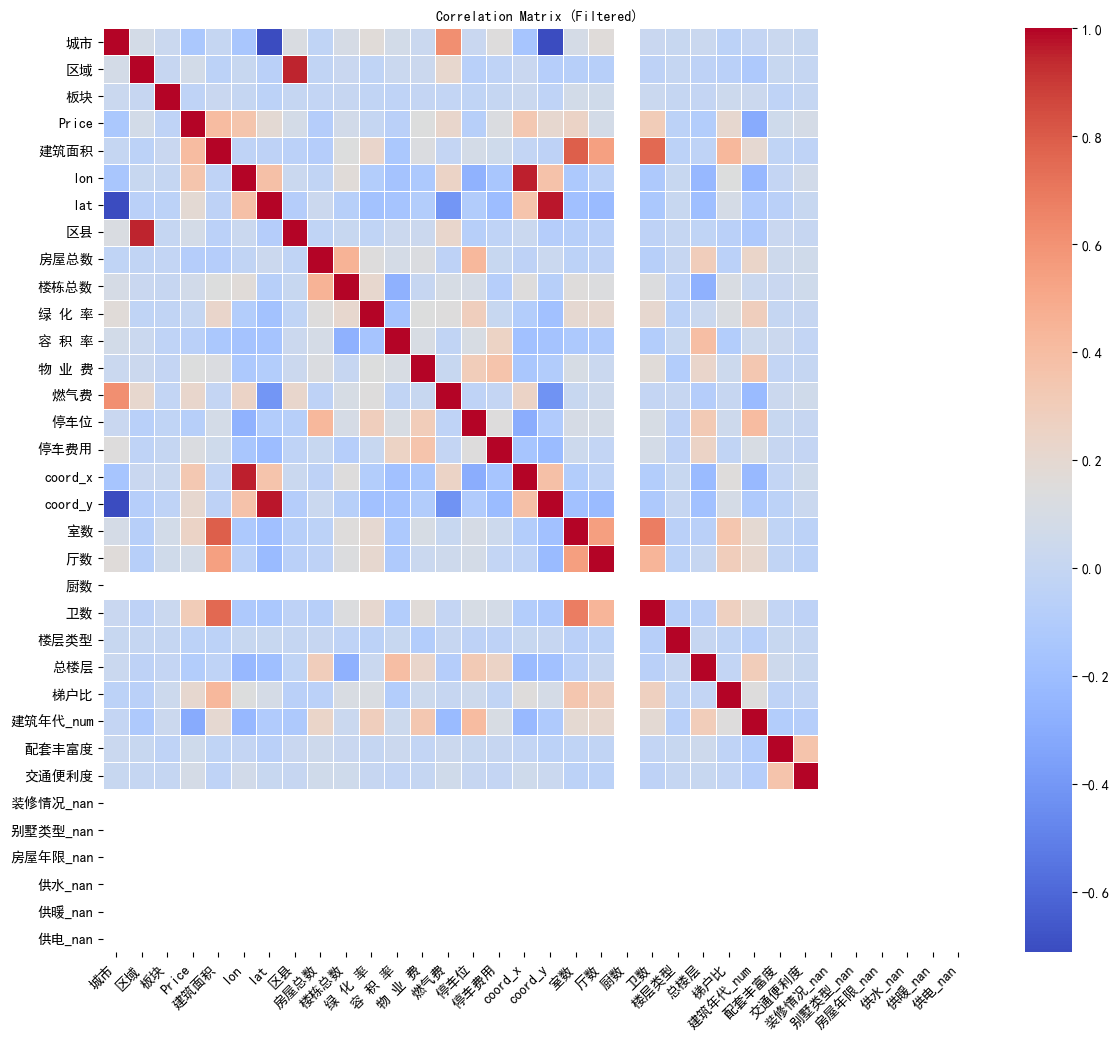

In [45]:
# Step 2: Correlation Analysis (Price)
def correlation_analysis(dfTrain, dfTest, target_column, high_corr_threshold=0.9, low_corr_threshold=0.1):
    # 仅在训练集上计算相关性
    dfTrain = dfTrain.select_dtypes(include=[np.number])
    corr_matrix_train = dfTrain.corr()
    
    # 找到与目标变量高度相关和低相关的特征
    high_corr_features = corr_matrix_train[target_column][abs(corr_matrix_train[target_column]) > high_corr_threshold].index.tolist()
    low_corr_features = corr_matrix_train[target_column][abs(corr_matrix_train[target_column]) < low_corr_threshold].index.tolist()

    # 不删除目标变量本身
    features_to_remove = [f for f in set(high_corr_features + low_corr_features) if f != target_column]
    print(f"Removed features with high or low correlation to target: {features_to_remove}")
    
    # 在训练集上删除这些特征
    dfTrain = dfTrain.drop(columns=features_to_remove, errors='ignore')
    
    # 在测试集和预测集上移除相同的特征
    dfTest = dfTest.drop(columns=features_to_remove, errors='ignore')
    
    return dfTrain, dfTest, corr_matrix_train

# 执行训练集的相关性分析
df_final_train, df_final_test, corr_matrix_train = correlation_analysis(df_final_train, df_final_test, target_column='Price')

# 展示最终的相关性热图
plt.figure(figsize=(14, 12))  # 调整图像大小
sns.heatmap(corr_matrix_train, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)  # 不展示相关系数
plt.title("Correlation Matrix (Filtered)", fontsize=20, fontproperties=font_prop)
plt.xticks(rotation=45, ha='right', fontsize=12, fontproperties=font_prop)
plt.yticks(rotation=0, fontsize=12, fontproperties=font_prop)
plt.show()


#### 2.4.2 VIF

In [46]:
# Step 3: VIF (方差膨胀系数)
# Step 3: 计算VIF并移除高VIF特征，仅在训练集上计算
def calculate_vif(dfTrain, dfTest, target_column='Price'):
    """
    计算VIF并移除高多重共线性特征，完全保护目标变量
    """
    print(f"=== VIF计算开始，保护目标列: {target_column} ===")
    
    # 检查目标列是否存在
    if target_column not in dfTrain.columns:
        print(f"Error: 目标列 '{target_column}' 不存在于数据框中!")
        return dfTrain, dfTest, []

    # 分离训练集的特征和目标变量
    target_series_train = dfTrain[target_column].copy()
    features_df_train = dfTrain.drop(columns=[target_column])
    
    # 确保训练集数据是数值型
    features_df_train = features_df_train.select_dtypes(include=[np.number])
    
    # 处理 NaN 和 Inf 数据
    features_df_train = features_df_train.replace([np.inf, -np.inf], np.nan)
    features_df_train = features_df_train.fillna(features_df_train.median())
    
    # 计算VIF值
    vif_data_train = pd.DataFrame()
    vif_data_train["features"] = features_df_train.columns
    vif_data_train["VIF"] = [variance_inflation_factor(features_df_train.values, i) for i in range(features_df_train.shape[1])]
    
    # 移除VIF值超过5的特征
    high_vif_features = vif_data_train[vif_data_train["VIF"] > 5]["features"].tolist()
    if high_vif_features:
        features_df_train = features_df_train.drop(columns=high_vif_features)
    
    # 重新组合训练数据
    dfTrain = pd.concat([features_df_train, target_series_train], axis=1)
    
    # 在验证集上删除相同的高VIF特征
    dfTest = dfTest.drop(columns=high_vif_features, errors='ignore')
    
    return dfTrain, dfTest, high_vif_features


# Step 3: VIF (完全保护Price列)

print("Before VIF calculation:")
print("数据框形状:", df_final_train.shape)
print("列名:", df_final_train.columns.tolist())
print("Price列数据类型:", df_final_train['Price'].dtype if 'Price' in df_final_train.columns else 'Not Found')

# 执行VIF计算
df_final_train, df_final_test, high_vif_features = calculate_vif(df_final_train, df_final_test, target_column='Price')

# 对预测集应用相同的特征删除
df_final_pred = df_final_pred.drop(columns=high_vif_features, errors='ignore')

print("After VIF calculation:")
print("数据框形状:", df_final_train.shape)
print("Price列是否保留:", 'Price' in df_final_train.columns)

if 'Price' in df_final_train.columns:
    print("Price列样本值:")
    print(df_final_train['Price'].head())
else:
    print("ERROR: Price列丢失了!")
    # 紧急恢复
    print("尝试恢复原始数据...")
    # 这里需要你重新加载或恢复原始数据


Before VIF calculation:
数据框形状: (83096, 21)
列名: ['城市', 'Price', '建筑面积', 'lon', 'lat', '物 业 费', '燃气费', '停车费用', 'coord_x', 'coord_y', '室数', '厨数', '卫数', '梯户比', '建筑年代_num', '装修情况_nan', '别墅类型_nan', '房屋年限_nan', '供水_nan', '供暖_nan', '供电_nan']
Price列数据类型: float64
=== VIF计算开始，保护目标列: Price ===
After VIF calculation:
数据框形状: (83096, 16)
Price列是否保留: True
Price列样本值:
20486    4.252795e+05
53134    3.727424e+06
8277     5.368957e+06
45156    4.765661e+05
99942    5.368957e+06
Name: Price, dtype: float64


In [47]:
# debug
print("After featuring:")
msg = df_final_train.info()
print(f"{msg}")
print(f"数据集形状: {df_final_train.shape}")
# 显示所有列名
print("列名:", df_final_train.columns.tolist())

After featuring:
<class 'pandas.core.frame.DataFrame'>
Index: 83096 entries, 20486 to 77652
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   城市        83096 non-null  int64  
 1   建筑面积      83096 non-null  float64
 2   物 业 费     83096 non-null  float64
 3   燃气费       83096 non-null  float64
 4   停车费用      83096 non-null  float64
 5   室数        83096 non-null  float64
 6   卫数        83096 non-null  float64
 7   梯户比       83096 non-null  float64
 8   建筑年代_num  83096 non-null  float64
 9   装修情况_nan  83096 non-null  float64
 10  别墅类型_nan  83096 non-null  float64
 11  房屋年限_nan  83096 non-null  float64
 12  供水_nan    83096 non-null  float64
 13  供暖_nan    83096 non-null  float64
 14  供电_nan    83096 non-null  float64
 15  Price     83096 non-null  float64
dtypes: float64(15), int64(1)
memory usage: 10.8 MB
None
数据集形状: (83096, 16)
列名: ['城市', '建筑面积', '物 业 费', '燃气费', '停车费用', '室数', '卫数', '梯户比', '建筑年代_num', '装修情况_nan', '别墅类型_nan',

In [48]:

# 仅在训练集上选取特征
target_column = 'Price'
train_features = df_final_train.drop(columns=[target_column])

# 训练集特征
X_train = train_features
y_train = df_final_train[target_column]

# 测试集特征：根据训练集选择的特征
X_test = df_final_test[train_features.columns]
y_test = df_final_test[target_column]

# 预测集特征：根据训练集选择的特征
X_pred = df_final_pred[train_features.columns]

## 3. Modeling

### 3.1 Basic linear model

In [51]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from datetime import datetime

def model_training_evaluation(models, X_train, y_train, X_test, y_test, X_pred, df_pred, isRent=False):
    """
    训练、评估并生成结果文件，仅输出MAE指标表格
    """
    start_time = datetime.now()
    kf = KFold(n_splits=6, shuffle=True, random_state=42)
    scaler = StandardScaler()

    print("4.0 特征标准化...")
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_pred_scaled = scaler.transform(X_pred)

    metrics_list = []  # 存储所有模型的结果

    for mode_name, model in models.items():
        print("\n" + "=" * 50)
        print(f"步骤4: {mode_name} 模型训练与评估")
        print("=" * 50)

        # ===== 1️⃣ 交叉验证 MAE =====
        cv_mae_scores = -cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')
        cv_mae = cv_mae_scores.mean()

        # ===== 2️⃣ 模型拟合 =====
        model.fit(X_train_scaled, y_train)

        # ===== 3️⃣ 预测 =====
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
        y_pred_pred = model.predict(X_pred_scaled)

        # ===== 4️⃣ 计算 MAE =====
        in_sample_mae = mean_absolute_error(y_train, y_train_pred)
        out_sample_mae = mean_absolute_error(y_test, y_test_pred)

        # ===== 5️⃣ 记录指标 =====
        metrics_list.append({
            'Metrics': mode_name,
            'In sample': in_sample_mae,
            'Out of sample': out_sample_mae,
            'Cross-validation': cv_mae
        })

        # ===== 6️⃣ 保存预测结果 =====
        # Save predictions if not rent data
        if not isRent:
            results_df = pd.DataFrame({'ID': df_pred['ID'], 'Price': y_pred_pred})
            output_file = f"{mode_name}_predict.csv"
            results_df.to_csv(output_file, index=False, mode='w', header=True)
            print(f"\n✅ 预测结果（{mode_name}）已保存到: {output_file}")
        else:
            results_df = pd.DataFrame({'ID': df_pred['ID'], 'Price': y_pred_pred})
            output_file = f"{mode_name}_predict.csv"
            results_df.to_csv(output_file, mode='a', header=False, index=False)
            print(f"\n✅ 预测结果（{mode_name}）已追加到: {output_file}")

    # ===== 汇总输出表格 =====
    metrics_df = pd.DataFrame(metrics_list)
    print("\n模型 MAE 结果汇总（越小越好）:")
    print(metrics_df.round(4))

    duration = datetime.now() - start_time
    print(f"\n总执行时长: {duration}")

    # Track the execution time
    current_time_end = datetime.now()
    duration = current_time_end - current_time_start
    print(f"总的执行时长: {duration}")
    return metrics_df
        
# Initialize models
lr = LinearRegression()
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=0.1)
elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5)

models = {'OLS': lr, 'Lasso': lasso, 'Ridge': ridge, 'ElasticNet': elasticnet}

# Call the function with the models

metrics_df = model_training_evaluation(
    models,
    X_train, y_train,
    X_test, y_test,   # ✅ 测试集标签
    X_pred, df_pred,  # ✅ 预测集数据及其ID
    isRent)

4.0 特征标准化...

步骤4: OLS 模型训练与评估

✅ 预测结果（OLS）已保存到: OLS_predict.csv

步骤4: Lasso 模型训练与评估

✅ 预测结果（Lasso）已保存到: Lasso_predict.csv

步骤4: Ridge 模型训练与评估

✅ 预测结果（Ridge）已保存到: Ridge_predict.csv

步骤4: ElasticNet 模型训练与评估

✅ 预测结果（ElasticNet）已保存到: ElasticNet_predict.csv

模型 MAE 结果汇总（越小越好）:
      Metrics    In sample  Out of sample  Cross-validation
0         OLS  799876.3410    801332.2268       800045.4603
1       Lasso  799876.3396    801332.2276       800045.4592
2       Ridge  799876.3297    801332.2326       800045.4471
3  ElasticNet  802832.5610    804620.8395       802988.4099

总执行时长: 0:00:06.078021
总的执行时长: 0:18:48.866392


### 3.2 Model tuning

#### 3.2.1 Polynomial features

In [52]:
# ======================== 生成多项式特征（非线性项） ========================
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_pred_scaled = scaler.transform(X_pred)

# 生成多项式特征
degree = 2  # 设置多项式阶数，可调节以提升模型非线性拟合能力
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
X_pred_poly = poly.transform(X_pred_scaled)

# ======================== 定义模型 ========================
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

models = {
    'OLS': LinearRegression(),
    'Lasso': Lasso(alpha=0.1),
    'Ridge': Ridge(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

# ======================== 模型训练与评估 ========================

metrics_df = model_training_evaluation(
    models,
    X_train_poly, y_train,
    X_test_poly, y_test,   # ✅ 测试集标签
    X_pred_poly, df_pred,  # ✅ 预测集数据及其ID
    isRent)

4.0 特征标准化...

步骤4: OLS 模型训练与评估

✅ 预测结果（OLS）已保存到: OLS_predict.csv

步骤4: Lasso 模型训练与评估

✅ 预测结果（Lasso）已保存到: Lasso_predict.csv

步骤4: Ridge 模型训练与评估

✅ 预测结果（Ridge）已保存到: Ridge_predict.csv

步骤4: ElasticNet 模型训练与评估

✅ 预测结果（ElasticNet）已保存到: ElasticNet_predict.csv

模型 MAE 结果汇总（越小越好）:
      Metrics    In sample  Out of sample  Cross-validation
0         OLS  691481.7884    692364.4388       692019.8823
1       Lasso  691481.8230    692364.4777       692019.9212
2       Ridge  691481.8764    692364.5836       692019.9868
3  ElasticNet  700553.9031    702705.8771       701038.1236

总执行时长: 0:01:11.709779
总的执行时长: 0:20:07.173366
